# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
#Seu código de importação aqui
df = pd.read_csv("churn_tratado.csv", delimiter=';')
df.head(20)


,id_cliente,genero,idoso,casado,dependents,tempo_como_cliente,servico_telefone,servico_internet,servico_seguranca,suporte_tecnico,canais_tv,tipo_contrato,metodo_pagamento,pagamento_mensal,total_pago,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
4,8191-XWSZG,F,0,No,No,52,Yes,No,No internet service,No internet service,No internet service,One year,Mailed check,71.45,1022.95,No
5,9959-WOFKT,Male,0,No,Yes,71,Yes,Fiber optic,Yes,No,Yes,Two year,Bank transfer (automatic),71.45,7382.25,No
6,4190-MFLUW,F,0,Yes,Yes,10,Yes,DSL,No,Yes,No,Month-to-month,Credit card (automatic),71.45,528.35,Yes
7,4183-MYFRB,F,0,No,No,21,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,1862.90,No
8,8779-QRDMV,Male,1,No,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,71.45,39.65,Yes
9,1680-VDCWW,Male,0,Yes,No,12,Yes,No,No internet service,No internet service,No internet service,One year,Bank transfer (automatic),71.45,202.25,No


In [3]:
df['genero'] = df['genero'].replace({
    'M': 'Male',
    'f': 'Female',
    'F': 'Female'
})

Legenda dos dados:

CustomerID : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

Genero : O genero dos nossos clientes.

Idoso : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

Casado : Se nosso cliente é casado ou não.

Dependents : Se cliente tem dependentes.

Tempo_como_Cliente : Tempo em meses que nosso cliente está com a nossa empresa.

PhoneService : Se ele contratou serviço telefônico com a nossa empresa.

Servico_Internet : Qual o tipo de serviço de internet contratado.

Servico_Seguranca : Se ele contratou serviço de segurança com a nossa empresa.

Suporte_Tecnico : Se já acionou o suporte técnico.

StreamingTV : Se ele contratou serviço de streaming para TV.

Tipo_Contrato : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

Tipo_Contrato : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

PaymentMethod : Forma de Pagamento.

Pagamento_Mensal : Quanto o cliente pagava mensalmente.

Total_Pago : Total já pago pelo cliente para nossa companhia.

Churn : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.

# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.
A variável idoso não trata da idade é apenas identificação de presença ou ausência, é binária e foi entendida como numérica. 
No caso do tempo com o cliente a media e a mediana estão distantes apenas 3 unidades o que indica uma distribuição relativamente simetrica com uma variablidade alta já que o dp é de 24. Já o pagamento mensal está apenas levemente mais distante do que no caso do tempo com o cliente indicando a presença de alguns poucos valores menores com uma variablidade alta já que o dp é de 28. Por fim, o total pago mostra a maior diferença entre média e mediana indicando a presença de outiliers e também apresenta um dp bem alto. 

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais? Sim, o total pago que mostra a maior diferença entre média e mediana indicando a presença de outiliers e também apresenta um dp bem alto sugerindo uma variabilidade alta entre os dados. 

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas. 

Tempo com o cliente: A empresa possui uma base de clientes relativamente diversa em diferentes estágios, uma parcela relevante dos clientes (25%) possui menos de 1 ano de relacionamento, também é possível perceber que metade da base ainda não atingiu nem 3 anos na empresa o que pode ser um fator importante para observação.

Suporte Técnico: O fato de uma parcela relevante dos clientes nunca ter acionado o suporte pode indicar ou uma experiência satisfatória sem necessidade de ajuda ou problemas para acessar o suporte. Já os clientes que acionaram o suporte podem ter enfrentado problemas, o que pode estar relacionado ao churn dependendo da qualidade do atendimento.

Pagamento Mensal: Os valores de pagamento mensal variam significativamente entre os clientes com a maior concentração entre 45 e 88 sendo o valor máximo pago 118 o que pode indicar a presença de diferentes planos e formas de contratar serviços variados. Alguns dos serviços podem ser mais bem aceitos que outros proporcionando uma maior ou menor fidelização e também podem ser pontos de atenção para melhora.

Idoso: A presença reduzida de apenas 16% de idosos não exclui sua importancia ou influência na analise de comportamentos como o de churn, pois representam um grupo específico que pode ter uma forte relação com o objeto do estudo.


D) Verifique se os dados das variáveis Booleanas são balanceados ou não. 
<br>
Gênero: Distribuição bem equilibrada entre os gêneros que usam os serviços.
<br>
Male      51.0
<br>
Female    49.0
<br>
Idoso: Desbalanceada, apenas uma mionoria dos clientes da base são idosos.
<br>
0    83.84
<br>
1    16.16
<br>
Casado: Distribuição equilibrada entre casados e não casados.
<br>
No     50.72
<br>
Yes    49.28
<br>
Dependente: Desbalanceada, predominância de clientes que não possuem dependentes.
<br>
No     68.53
<br>
Yes    31.47
<br>
Servico de telefone: Desbalanceada, leve predominância de clientes que não usam o serviço
<br>
No     63.02
<br>
Yes    36.98
<br>
Churn: Desbalanceada, a maioria dos clientes da base não fez churn.
<br>
No     74.0
<br>
Yes    26.0
<br>


In [4]:
#Seu código aqui
print(df.describe())
print(df.columns)

             idoso  tempo_como_cliente  pagamento_mensal   total_pago
count  2488.000000         2488.000000       2488.000000  2488.000000
mean      0.161576           32.352090         66.342564  2290.087178
std       0.368135           24.636885         28.051718  2264.585643
min       0.000000            0.000000         18.400000    18.800000
25%       0.000000            8.000000         45.400000   402.337500
50%       0.000000           29.000000         71.450000  1402.900000
75%       0.000000           56.000000         87.712500  3867.162500
max       1.000000           72.000000        118.650000  8564.750000
Index(['id_cliente', 'genero', 'idoso', 'casado', 'dependents',
       'tempo_como_cliente', 'servico_telefone', 'servico_internet',
       'servico_seguranca', 'suporte_tecnico', 'canais_tv', 'tipo_contrato',
       'metodo_pagamento', 'pagamento_mensal', 'total_pago', 'churn'],
      dtype='str')


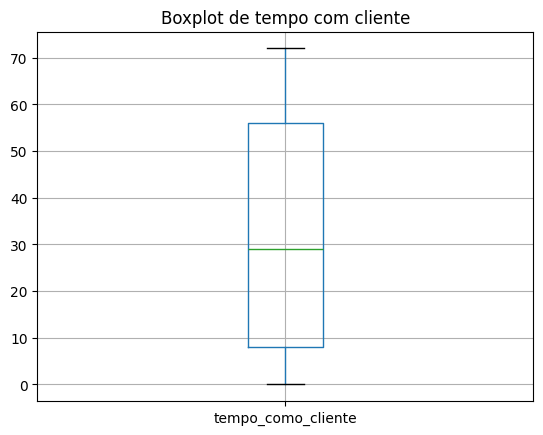

In [5]:
df.boxplot(column='tempo_como_cliente')
plt.title('Boxplot de tempo com cliente')
plt.show()

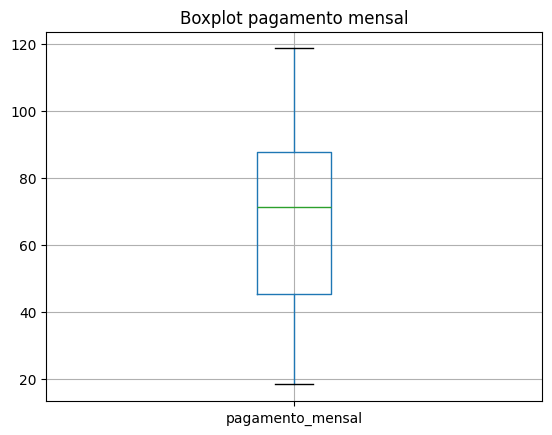

In [6]:
df.boxplot(column='pagamento_mensal')
plt.title('Boxplot pagamento mensal')
plt.show()

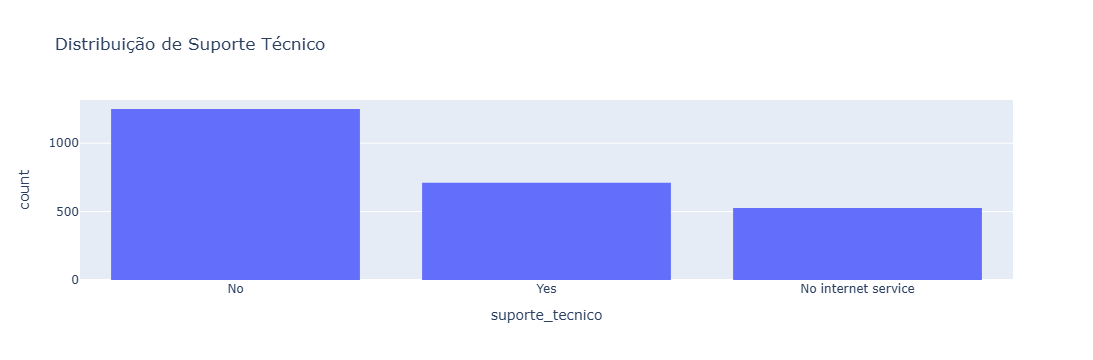

suporte_tecnico
No                     50.241158
Yes                    28.577170
No internet service    21.181672
Name: proportion, dtype: float64

In [7]:
fig = px.histogram(
    df,
    x='suporte_tecnico',
    title='Distribuição de Suporte Técnico'
)

fig.show()

df['suporte_tecnico'].value_counts(normalize=True) * 100

In [8]:
import plotly.express as px

fig = px.histogram(
    df,
    x='idoso',
    title='Distribuição de Idosos',
    text_auto=True
)

fig.show()

percentual = df['idoso'].value_counts(normalize=True) * 100
print(percentual.round(2))


idoso
0    83.84
1    16.16
Name: proportion, dtype: float64



 genero
genero
Male      51.0
Female    49.0
Name: proportion, dtype: float64

 idoso
idoso
0    83.84
1    16.16
Name: proportion, dtype: float64

 casado
casado
No     50.72
Yes    49.28
Name: proportion, dtype: float64

 dependents
dependents
No     68.53
Yes    31.47
Name: proportion, dtype: float64

 servico_telefone
servico_telefone
No     63.02
Yes    36.98
Name: proportion, dtype: float64

 churn
churn
No     74.0
Yes    26.0
Name: proportion, dtype: float64


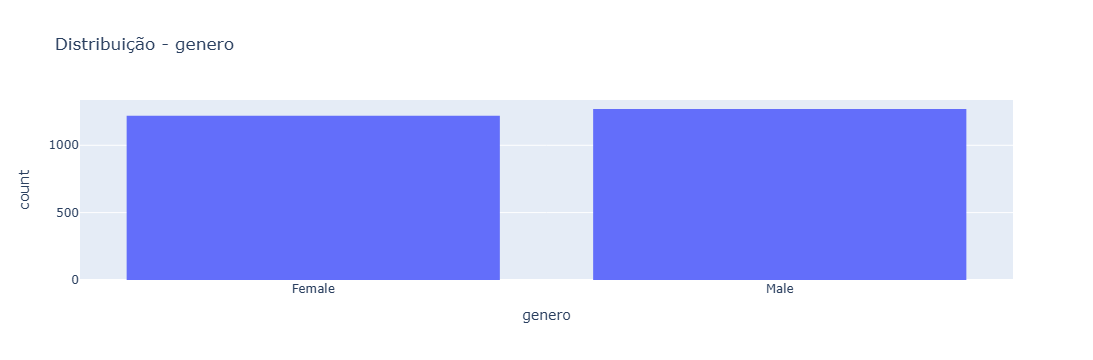

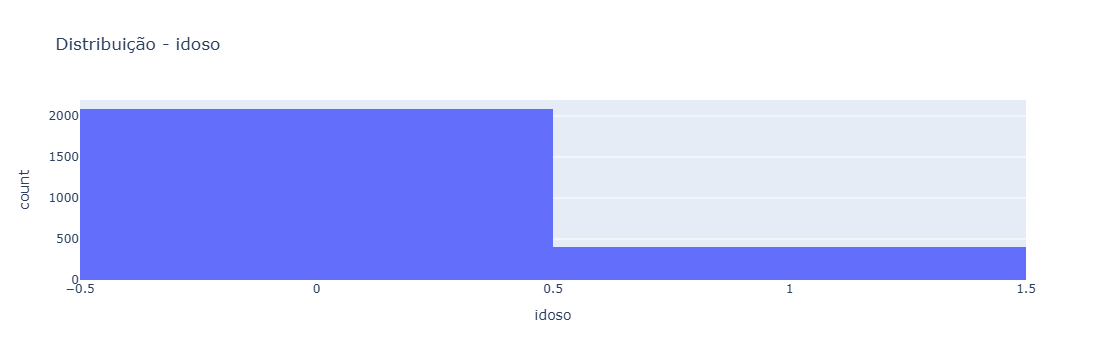

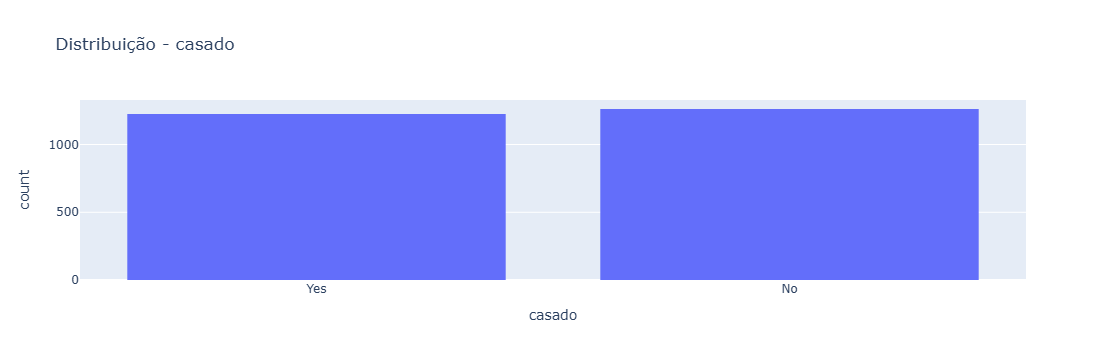

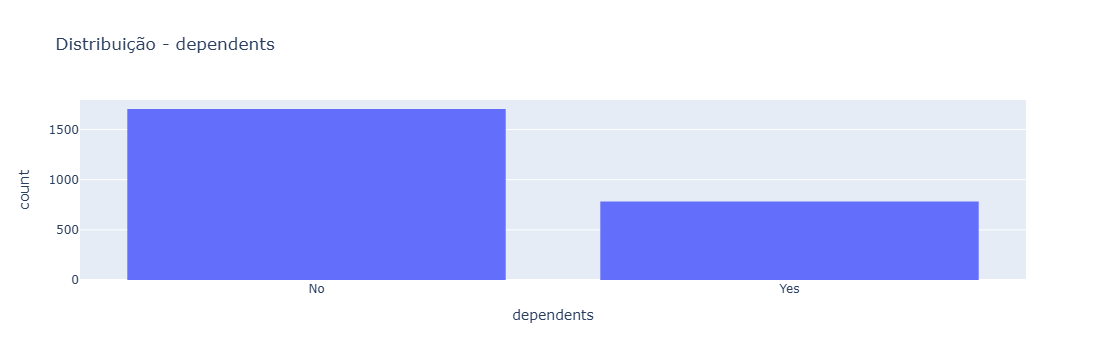

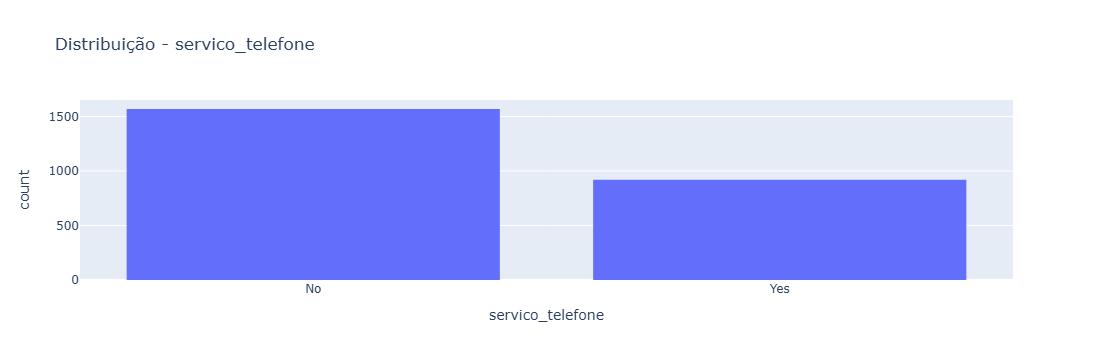

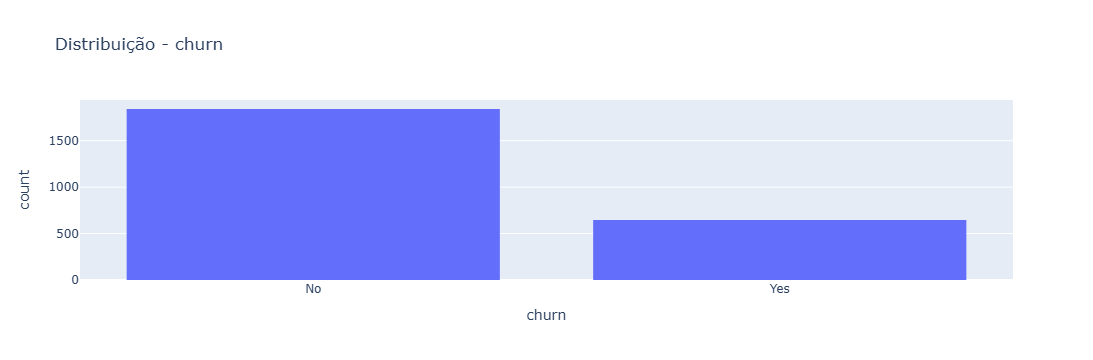

In [9]:
#já pega logo todas as variáveis e faz os processos
variaveis = [
    'genero',
    'idoso',
    'casado',
    'dependents',
    'servico_telefone',    
    'churn'
]
#faz o looping começando com o nome de kd uma dps calcula a porcentagem e traz o gráfico
for var in variaveis:
    print(f'\n {var}')
    print((df[var].value_counts(normalize=True) * 100).round(2))


for var in variaveis:
    fig = px.histogram(df, x=var, title=f'Distribuição - {var}')
    fig.show()
    

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


In [10]:

Q1 = df['total_pago'].quantile(0.25)
Q3 = df['total_pago'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df.loc[
    (df['total_pago'] < limite_inferior) | 
    (df['total_pago'] > limite_superior),
    ['total_pago']
]

print(outliers)


Empty DataFrame
Columns: [total_pago]
Index: []


Ainda que o maior e menor valor estejam muito distantes também é preciso levar em consideração que os tempos de permanência dos clientes são diversos e por ser um acumulado é esperada uma certa variação desse valor.

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.

Clientes mais recentes estão mais propensos ao churn? Dentro dos dados é possível verificar que muitos clientes deixam a empresa logo no início. Passando dos 37 meses os clientes tendem a nao deixar o serviço apenas alguns poucos. Portanto, é preciso ter um olhar atento para os clientes mais novos para evitar a evasão. 
<br>
Clientes com maior valor de pagamento mensal estão mais propensos ao churn? Sim, a maior parte dos clientes paga entre 31 e 84 se mantém contratando os serviços da empresa. Entretanto, também é possível observar que os clientes que dão churn estão distribuídos com os maiores pagamentos mensais entre 70 e 93 e alguns poucos abaixo de 35 o que pode ser um indicativo dos clientes novos que cancelaram os serviços.
<br>
O tipo de contrato influencia o churn? Sim, os clientes com contrato mensal apresentam uma tendência maior a cancelarem o serviço quando comparados aos outros tipos de contrato e também representam uma parte significativa da base de clientes presente no banco de dados. 
<br>
Clientes que já pagaram mais fazem menos churn? Sim, clientes com maior valor total pago tendem a permanecer na empresa. Mas, isso não significa necessariamente que pagar mais reduz o churn. Esse padrão provavelmente é resultado de que clientes mais antigos acumulam maior valor ao longo do tempo, enquanto clientes mais recentes com menor valor pago tendem a pedir o cancelamento.
<br>
O suporte técnico impacta o churn? Sim, a presença de suporte técnico está associada a menores níveis de churn, já que os clientes sem suporte tendem a fazer mais cancelamentos.
<br>

B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn? As usadas inicialmente para criação das hipóteses. Mas com destaque para as variáveis suporte técnico e tipo de contrato que indicaram a evasão e clientes de forma mais acentuada em contratos mensais e acesso a suporte para resolução de problemas. 

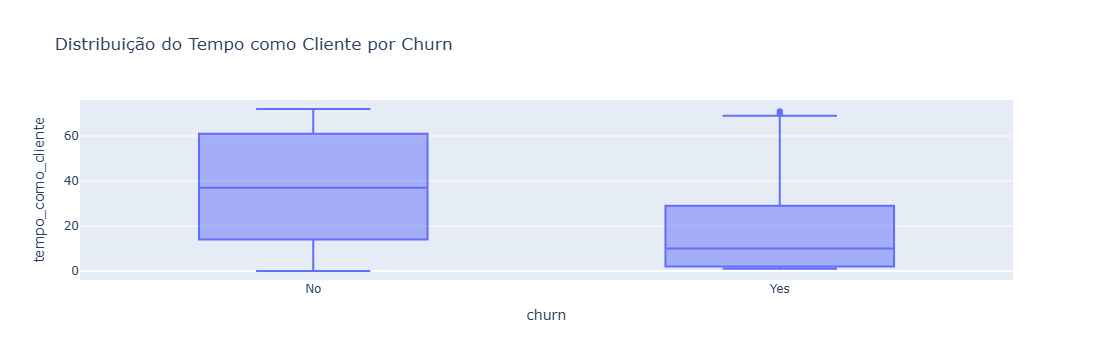

In [14]:
fig = px.box(
    df,
    x='churn',
    y='tempo_como_cliente',
    title='Tempo como Cliente por Churn'
)

fig.show()

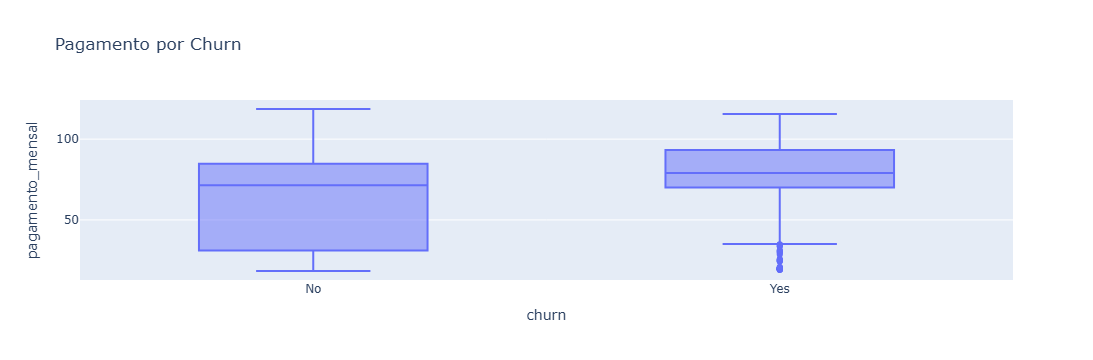

In [15]:
fig = px.box(
    df,
    x='churn',
    y='pagamento_mensal',
    title='Pagamento por Churn'
)

fig.show()

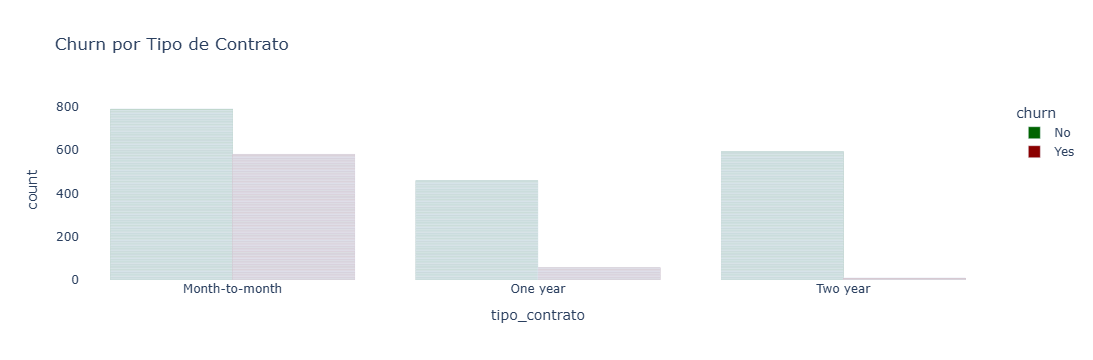

tipo_contrato
Month-to-month    1369
Two year           602
One year           517
Name: count, dtype: int64

In [30]:
fig = px.bar(
    df,
    x='tipo_contrato',
    color='churn',
    barmode='group',
    title='Churn por Tipo de Contrato',
    color_discrete_map={
         'Yes': '#8B0000',
         'No': '#006400'
    }
)

fig.update_layout(
    plot_bgcolor='white',   
    paper_bgcolor='white'   
)

fig.show()

df['tipo_contrato'].unique()
df['tipo_contrato'].value_counts()

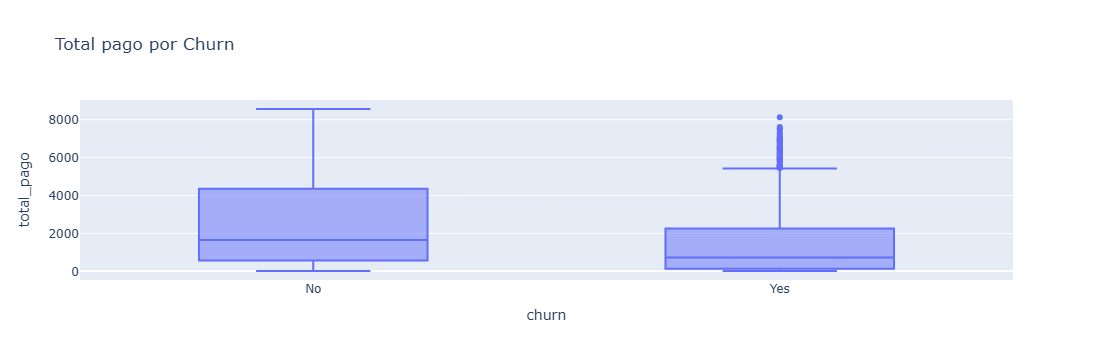

In [27]:
fig = px.box(
    df,
    x='churn',
    y='total_pago',
    title='Total pago por Churn'
)

fig.show()


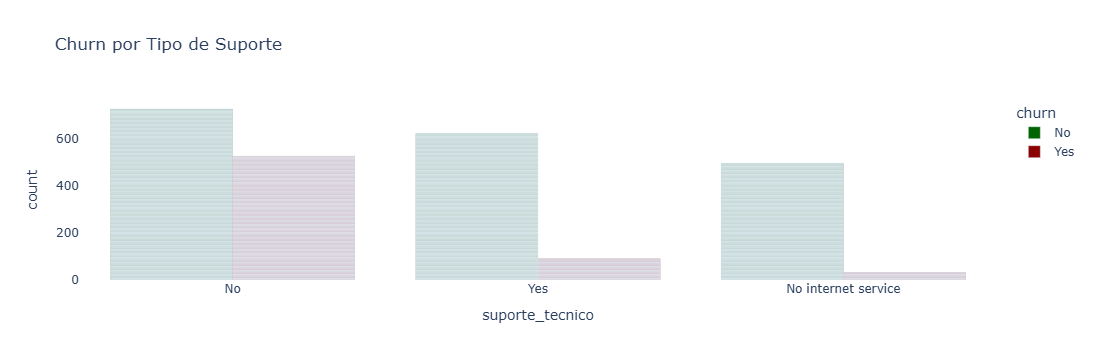

In [29]:
fig = px.bar(
    df,
    x='suporte_tecnico',
    color='churn',
    barmode='group',
    title='Churn por Tipo de Suporte',
    color_discrete_map={
         'Yes': '#8B0000',
         'No': '#006400'
    }
)

fig.update_layout(
    plot_bgcolor='white',   
    paper_bgcolor='white'   
)

fig.show()